# DeepSKAN Qualitative Analysis Notebook (MSL) — Improved Report Figures

This notebook duplicates the DeepSKAN MSL pipeline and saves improved qualitative figures for the report. The original training notebook is not modified.

In [ ]:

# Cell 1 — Install dependencies and clone repositories

!pip install --upgrade pip
!pip install torch torchinfo tqdm numpy scikit-learn matplotlib pandas toml

!rm -rf /content/KAN-AD
!rm -rf /content/datasets

!git clone https://github.com/CSTCloudOps/KAN-AD.git /content/KAN-AD
!git clone https://github.com/CSTCloudOps/datasets.git /content/datasets

!rm -rf /content/KAN-AD/datasets
!mv /content/datasets /content/KAN-AD/datasets

%cd /content/KAN-AD

Cloning into '/content/KAN-AD'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
Receiving objects: 100% (18/18), 61.77 KiB | 878.00 KiB/s, done.
remote: Total 18 (delta 1), reused 15 (delta 1), pack-reused 0 (from 0)
Resolving deltas: 100% (1/1), done.
Cloning into '/content/datasets'...
remote: Enumerating objects: 4503, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 4503 (delta 2), reused 0 (delta 0), pack-reused 4496 (from 3)
Receiving objects: 100% (4503/4503), 262.52 MiB | 7.36 MiB/s, done.
Resolving deltas: 100% (1962/1962), done.
Updating files: 100% (5564/5564), done.
/content/KAN-AD


In [ ]:

# Cell 2 — Install EasyTSAD, fix import syntax issue, and configure paths

!pip install git+https://github.com/CSTCloudOps/EasyTSAD.git
!sed -i 's/TSData,*/TSData/g' /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py || true
!grep -n "TSData" /usr/local/lib/python3.*/dist-packages/EasyTSAD/DataFactory/__init__.py | head -n 20

import os
import sys
import glob

REPO_ROOT = "/content/KAN-AD"
DATA_ROOT = "/content/KAN-AD/datasets"

sys.path.insert(0, REPO_ROOT)

candidates = glob.glob("/content/KAN-AD/**/kanad/kanad.py", recursive=True)
print("Found KAN-AD candidates:", candidates)
assert candidates, "Could not find kanad/kanad.py inside the cloned KAN-AD repo."

KANAD_PY = sorted(candidates, key=len)[0]
KANAD_PKG_DIR = os.path.dirname(KANAD_PY)
KANAD_ROOT_DIR = os.path.dirname(KANAD_PKG_DIR)

sys.path.insert(0, KANAD_ROOT_DIR)

print("KANAD_PKG_DIR =", KANAD_PKG_DIR)
print("KANAD_ROOT_DIR =", KANAD_ROOT_DIR)
print("sys.path[:4] =", sys.path[:4])

  Cloning https://github.com/CSTCloudOps/EasyTSAD.git to /tmp/pip-req-build-zjo4mgp_
  Running command git clone --filter=blob:none --quiet https://github.com/CSTCloudOps/EasyTSAD.git /tmp/pip-req-build-zjo4mgp_
  Resolved https://github.com/CSTCloudOps/EasyTSAD.git to commit b178ed4bdb63a2a896729fc21e09d6adf250028e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
1:from .TSData import TSData
2:from .MTSData import MTSData
Found KAN-AD candidates: ['/content/KAN-AD/kanad/kanad.py']
KANAD_PKG_DIR = /content/KAN-AD/kanad
KANAD_ROOT_DIR = /content/KAN-AD
sys.path[:4] = ['/content/KAN-AD', '/content/KAN-AD', '/content', '/env/python']


In [ ]:

# Cell 3 — Imports and sanity check

import json
import math
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

from torch.utils.data import Dataset, DataLoader

from EasyTSAD.Controller import TSADController
from EasyTSAD.DataFactory import TSData
from EasyTSAD.Methods import BaseMethod
from EasyTSAD.Evaluations.Protocols import (
    EventF1PA,
    PointF1PA,
    PointKthF1PA,
    PointAuprcPA,
)

from kanad import KANAD
from kanad.kanad import KANADModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("KANAD imported:", KANAD)
print("KANADModel imported:", KANADModel)
print("TSADController imported:", TSADController)

Device: cuda
KANAD imported: <class 'kanad.kanad.KANAD'>
KANADModel imported: <class 'kanad.kanad.KANADModel'>
TSADController imported: <class 'EasyTSAD.Controller.TSADController.TSADController'>


In [ ]:
# Cell 4 — Define the Wavelet-based KAN-AD backbone helpers + sensor attention

class PeriodicIndexBasisLayer(nn.Module):
    def __init__(self, order: int, window: int):
        super().__init__()
        self.order = int(order)
        self.window = int(window)
        idx = torch.arange(self.window, dtype=torch.float32)
        self.register_buffer("idx", idx)

    def forward(self, x):
        B, W = x.shape
        feats = []
        t = self.idx.to(x.device)
        for n in range(1, self.order + 1):
            feats.append(torch.sin(2.0 * math.pi * n * t / self.window).view(1, 1, W).repeat(B, 1, 1))
            feats.append(torch.cos(2.0 * math.pi * n * t / self.window).view(1, 1, W).repeat(B, 1, 1))
        return torch.cat(feats, dim=1) if feats else torch.empty(B, 0, W, device=x.device)


class WaveletBasisLayer(nn.Module):
    """
    Morlet wavelet family (commonly used in KAN-AD wavelet variants)
    ψ(x) = cos(ωx) * exp(-x^2 / s^2)
    """

    def __init__(self, n_scales: int = 4):
        super().__init__()
        self.n_scales = int(n_scales)

        scales = torch.linspace(0.5, 2.0, self.n_scales)
        self.register_buffer("scales", scales)

    def forward(self, x):
        x = x.unsqueeze(1)  # (B, 1, W)
        s = self.scales.view(1, -1, 1)  # (1, S, 1)

        # Morlet wavelet
        wavelet = torch.cos(x / s) * torch.exp(-(x ** 2) / (s ** 2 + 1e-8))
        return wavelet


class WaveletKANADModel(nn.Module):
    """
    Wavelet-based KAN-AD backbone
    """

    def __init__(self, window: int, order: int = 2, family_channels: int = 4):
        super().__init__()

        self.window = int(window)
        self.order = int(order)
        self.family_channels = int(family_channels)

        # 🔥 Wavelet replaces Fourier/RBF
        self.family_layer = WaveletBasisLayer(n_scales=self.family_channels)
        self.family_out_channels = self.family_channels

        self.periodic_layer = PeriodicIndexBasisLayer(order=self.order, window=self.window)
        self.periodic_out_channels = 2 * self.order

        self.channels = self.family_out_channels + self.periodic_out_channels + 1

        self.init_conv = nn.Conv1d(self.channels, self.channels, kernel_size=3, padding=1, bias=False)
        self.inner_conv = nn.Conv1d(self.channels, self.channels, kernel_size=3, padding=1, bias=False)
        self.out_conv = nn.Conv1d(self.channels, 1, kernel_size=1, bias=False)
        self.final_conv = nn.Conv1d(1, 1, kernel_size=self.window)

        self.bn1 = nn.BatchNorm1d(self.channels)
        self.bn2 = nn.BatchNorm1d(self.channels)
        self.bn3 = nn.BatchNorm1d(1)
        self.act = nn.GELU()

    def forward_feature(self, x: torch.Tensor):
        raw = x.unsqueeze(1)

        # 🔥 Wavelet basis
        family = self.family_layer(x)

        periodic = self.periodic_layer(x)

        ff = torch.cat([family, periodic, raw], dim=1)

        res0 = raw
        res1 = ff

        ff = self.act(self.bn1(self.init_conv(ff)))
        ff = self.act(self.bn2(self.inner_conv(ff) + res1))
        ff = self.act(self.bn3(self.out_conv(ff) + res0))

        return ff

    def forward_head(self, ff: torch.Tensor):
        return self.final_conv(ff).squeeze(1)

    def forward(self, x: torch.Tensor):
        ff = self.forward_feature(x)
        return self.forward_head(ff)


# ✅ KEEP ATTENTION EXACTLY SAME
class SensorSelfAttention(nn.Module):
    def __init__(self, n_features: int, d_model: int = 16, n_heads: int = 2, dropout: float = 0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_features = int(n_features)
        self.embed = nn.Linear(1, d_model)
        self.mha = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.out = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B, T, F = x.shape

        xt = x.reshape(B * T, F, 1)
        z = self.embed(xt)

        if return_attn:
            z_attn, attn = self.mha(z, z, z, need_weights=True, average_attn_weights=True)
            attn_avg = attn.mean(dim=0)
        else:
            z_attn, _ = self.mha(z, z, z, need_weights=False)
            attn_avg = None

        y = self.out(z_attn).squeeze(-1)
        x_mix = y.reshape(B, T, F)

        return x_mix, attn_avg


print("Wavelet FastKANADModel + SensorSelfAttention ready.")

Wavelet FastKANADModel + SensorSelfAttention ready.


In [ ]:
# Cell 5 — Build MSL holdout dataset + save calibration arrays outside EasyTSAD tree

import os
import shutil
import numpy as np

# -----------------------------
# Basic paths / names
# -----------------------------
ROOT_DIR = "/content/KAN-AD"
DATA_ROOT = os.path.join(ROOT_DIR, "datasets", "MTS")

ORIG_DATASET = "MSL"                       # ✅ CHANGED
CUSTOM_DATASET = "MSL_HybridHoldout"       # ✅ CHANGED

orig_curve_dir = os.path.join(DATA_ROOT, ORIG_DATASET, "AllInOne")
custom_dataset_dir = os.path.join(DATA_ROOT, CUSTOM_DATASET)
custom_curve_dir = os.path.join(custom_dataset_dir, "AllInOne")

print("Original MSL curve dir:", orig_curve_dir)

# -----------------------------
# Load original MSL arrays
# -----------------------------
train = np.load(os.path.join(orig_curve_dir, "train.npy"))
test = np.load(os.path.join(orig_curve_dir, "test.npy"))

train_label_path = os.path.join(orig_curve_dir, "train_label.npy")
test_label_path = os.path.join(orig_curve_dir, "test_label.npy")

if os.path.exists(train_label_path):
    train_label = np.load(train_label_path)
else:
    train_label = np.zeros(len(train), dtype=np.int64)

if os.path.exists(test_label_path):
    test_label = np.load(test_label_path)
else:
    raise FileNotFoundError(f"Missing test labels: {test_label_path}")

print("train shape:", train.shape)
print("test shape :", test.shape)
print("train_label shape:", train_label.shape, " positives:", int(train_label.sum()))
print("test_label shape :", test_label.shape, " positives:", int(test_label.sum()))

# -----------------------------
# Calibration split (⚠️ MSL-specific tweak)
# -----------------------------
test_len = len(test)

# 🔥 MSL needs slightly larger calibration (anomalies are sparse)
default_calib_end = int(0.30 * test_len)   # ✅ CHANGED (was 20%)

positive_idx = np.where(test_label > 0)[0]
if len(positive_idx) == 0:
    raise ValueError("MSL test labels contain no anomalies.")

# ensure we include enough anomaly segments
last_pos = int(positive_idx[min(len(positive_idx) - 1, max(5, int(0.20 * len(positive_idx))))])

calib_end = max(default_calib_end, last_pos + 1)
calib_end = min(calib_end, test_len - 1)

calib_arr = test[:calib_end].copy()
calib_label = test_label[:calib_end].copy()

final_test = test[calib_end:].copy()
final_test_label = test_label[calib_end:].copy()

print("\nChosen calibration end index:", calib_end)
print("Calibration shape:", calib_arr.shape, " positives:", int(calib_label.sum()))
print("Final test shape :", final_test.shape, " positives:", int(final_test_label.sum()))

if calib_label.sum() == 0:
    raise ValueError("Calibration split still has no anomalies.")

# -----------------------------
# Rebuild dataset tree
# -----------------------------
if os.path.exists(custom_dataset_dir):
    shutil.rmtree(custom_dataset_dir)

os.makedirs(custom_curve_dir, exist_ok=True)

np.save(os.path.join(custom_curve_dir, "train.npy"), train)
np.save(os.path.join(custom_curve_dir, "train_label.npy"), train_label)
np.save(os.path.join(custom_curve_dir, "test.npy"), final_test)
np.save(os.path.join(custom_curve_dir, "test_label.npy"), final_test_label)

# copy metadata
for extra_name in ["info.json", "meta.json"]:
    src = os.path.join(orig_curve_dir, extra_name)
    dst = os.path.join(custom_curve_dir, extra_name)
    if os.path.exists(src):
        shutil.copy2(src, dst)

# -----------------------------
# Save calibration arrays
# -----------------------------
RUNTIME_DIR = os.path.join(ROOT_DIR, "kanad_runtime")
os.makedirs(RUNTIME_DIR, exist_ok=True)

CALIB_DIR = os.path.join(RUNTIME_DIR, f"{CUSTOM_DATASET}_calibration")
if os.path.exists(CALIB_DIR):
    shutil.rmtree(CALIB_DIR)
os.makedirs(CALIB_DIR, exist_ok=True)

np.save(os.path.join(CALIB_DIR, "calib.npy"), calib_arr)
np.save(os.path.join(CALIB_DIR, "calib_label.npy"), calib_label)

# -----------------------------
# Sanity checks
# -----------------------------
print("\nCreated EasyTSAD dataset at:", custom_curve_dir)
print("Saved files:", sorted(os.listdir(custom_curve_dir)))

print("\nCalibration dir:", CALIB_DIR)
print("Calibration files:", sorted(os.listdir(CALIB_DIR)))

assert os.path.exists(os.path.join(custom_curve_dir, "train.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "test.npy"))
assert os.path.exists(os.path.join(custom_curve_dir, "test_label.npy"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib.npy"))
assert os.path.exists(os.path.join(CALIB_DIR, "calib_label.npy"))

print("\nCell 5 completed successfully.")

Original MSL curve dir: /content/KAN-AD/datasets/MTS/MSL/AllInOne
train shape: (58317, 55)
test shape : (73729, 55)
train_label shape: (58317,)  positives: 0
test_label shape : (73729,)  positives: 7766

Chosen calibration end index: 22118
Calibration shape: (22118, 55)  positives: 2608
Final test shape : (51611, 55)  positives: 5158

Created EasyTSAD dataset at: /content/KAN-AD/datasets/MTS/MSL_HybridHoldout/AllInOne
Saved files: ['info.json', 'test.npy', 'test_label.npy', 'train.npy', 'train_label.npy']

Calibration dir: /content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration
Calibration files: ['calib.npy', 'calib_label.npy']

Cell 5 completed successfully.


In [ ]:

# Cell 6 — Utility functions: segmentation, calibration F1 search, normalization, plotting

def contiguous_segments(binary_labels: np.ndarray):
    y = np.asarray(binary_labels).astype(int)
    segs = []
    start = None
    for i, v in enumerate(y):
        if v == 1 and start is None:
            start = i
        elif v == 0 and start is not None:
            segs.append((start, i - 1))
            start = None
    if start is not None:
        segs.append((start, len(y) - 1))
    return segs


def segment_overlap(a, b):
    return not (a[1] < b[0] or b[1] < a[0])


def event_f1_from_binary(pred_binary: np.ndarray, true_binary: np.ndarray):
    gt_segs = contiguous_segments(true_binary)
    pr_segs = contiguous_segments(pred_binary)

    if len(gt_segs) == 0 and len(pr_segs) == 0:
        return 1.0, 1.0, 1.0
    if len(gt_segs) == 0:
        return 0.0, 0.0, 0.0
    if len(pr_segs) == 0:
        return 0.0, 0.0, 0.0

    used_pr = set()
    tp = 0
    for gt in gt_segs:
        for j, pr in enumerate(pr_segs):
            if j in used_pr:
                continue
            if segment_overlap(gt, pr):
                tp += 1
                used_pr.add(j)
                break

    precision = tp / max(len(pr_segs), 1)
    recall = tp / max(len(gt_segs), 1)
    f1 = 0.0 if (precision + recall == 0) else 2 * precision * recall / (precision + recall)
    return f1, precision, recall


def best_event_f1_threshold(scores: np.ndarray, labels: np.ndarray, n_grid: int = 200):
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels).astype(int)

    if labels.sum() == 0:
        return 0.0, float(np.max(scores)), 0.0, 0.0

    lo = float(np.min(scores))
    hi = float(np.max(scores))

    if not np.isfinite(lo) or not np.isfinite(hi):
        raise ValueError("Non-finite scores encountered during threshold search.")

    if hi <= lo:
        pred = (scores > lo).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        return f1, lo, p, r

    thresholds = np.linspace(lo, hi, n_grid)
    best = (-1.0, lo, 0.0, 0.0)

    for thr in thresholds:
        pred = (scores > thr).astype(int)
        f1, p, r = event_f1_from_binary(pred, labels)
        if f1 > best[0]:
            best = (f1, float(thr), float(p), float(r))

    return best


def sigmoid_np(x):
    x = np.clip(x, -8.0, 8.0)
    return 1.0 / (1.0 + np.exp(-x))


def zscore_sigmoid(x, mu, std, eps=1e-8):
    z = (x - mu) / (std + eps)
    return sigmoid_np(z)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def show_overlay(scores, labels, title, max_points=4000):
    n = min(len(scores), max_points)
    x = np.arange(n)
    plt.figure(figsize=(14, 4))
    plt.plot(x, scores[:n], label="score")
    if labels is not None and n > 0:
        ymax = max(1e-6, float(np.max(scores[:n])))
        plt.fill_between(x, 0, ymax, where=labels[:n].astype(bool), alpha=0.2, step="pre", label="anomaly")
    plt.title(title)
    plt.legend()
    plt.show()

In [ ]:

# Cell 7 — Window datasets for train/valid/test and calibration

class MTSWindowDataset(Dataset):
    def __init__(self, tsData, phase, window_size):
        self.window_size = int(window_size)

        if phase == "train":
            self.data = np.asarray(tsData.train)
        elif phase == "valid":
            self.data = np.asarray(tsData.valid)
        elif phase == "test":
            self.data = np.asarray(tsData.test)
        else:
            raise ValueError("phase must be train / valid / test")

        assert self.data.ndim == 2, f"Expected 2D MTS array, got {self.data.shape}"
        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


class ArrayWindowDataset(Dataset):
    def __init__(self, data: np.ndarray, labels: np.ndarray, window_size: int):
        self.data = np.asarray(data)
        self.labels = np.asarray(labels).astype(int)
        self.window_size = int(window_size)

        assert self.data.ndim == 2, f"Expected 2D array, got {self.data.shape}"
        assert len(self.data) == len(self.labels), "Data/label length mismatch"

        self.N, self.F = self.data.shape
        self.sample_num = max(self.N - self.window_size, 0)

    def __len__(self):
        return self.sample_num

    def __getitem__(self, idx):
        x = self.data[idx:idx + self.window_size]
        y = self.data[idx + self.window_size]
        label = self.labels[idx + self.window_size]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long),
        )

print("Datasets ready.")

Datasets ready.


In [ ]:

# Cell 8 — Define DeepSKAN with qualitative-output saving (MSL)

class Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout(BaseMethod):
    def __init__(self, params: dict) -> None:
        super().__init__()

        self.__anomaly_score = None

        self.batch_size = int(params["batch_size"])
        self.window = int(params["window"])
        self.order = int(params["order"])
        self.epochs = int(params["epochs"])
        self.lr = float(params["lr"])

        self.lambda_svdd = float(params.get("lambda_svdd", 0.1))
        self.emb_dim = int(params.get("emb_dim", 64))
        self.patience = int(params.get("patience", 6))

        self.alpha_grid = params.get("alpha_grid", [round(x, 2) for x in np.linspace(0, 1, 11)])
        self.calib_data_path = params["calib_data_path"]
        self.calib_label_path = params["calib_label_path"]

        # Optional path where the test_phase will save qualitative arrays
        self.qualitative_output_path = params.get(
            "qualitative_output_path",
            "/content/KAN-AD/qualitative_outputs/DeepSKAN_MSL_HybridHoldout_qualitative.npz"
        )

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # SWaT has 51 features
        self.n_features = int(params.get("n_features", 51))
        self.attn_d_model = int(params.get("attn_d_model", 16))
        self.attn_heads = int(params.get("attn_heads", 2))
        self.attn_dropout = float(params.get("attn_dropout", 0.0))

        self.model = WaveletKANADModel(
            window=self.window,
            order=self.order,
        ).to(self.device)

        self.sensor_attn = SensorSelfAttention(
            n_features=self.n_features,
            d_model=self.attn_d_model,
            n_heads=self.attn_heads,
            dropout=self.attn_dropout,
        ).to(self.device)

        self.embed_head = nn.Sequential(
            nn.Linear(self.window, 128),
            nn.GELU(),
            nn.Linear(128, self.emb_dim),
        ).to(self.device)

        self.optimizer = optim.Adam(
            list(self.model.parameters()) +
            list(self.sensor_attn.parameters()) +
            list(self.embed_head.parameters()),
            lr=self.lr
        )
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=5, gamma=0.75)
        self.mse_loss = nn.MSELoss()

        self.center = None
        self.last_attn_matrix = None

        self.pred_mu = None
        self.pred_std = None
        self.svdd_mu = None
        self.svdd_std = None

        self.alpha = 0.5
        self.best_calib_event_f1 = None
        self.best_calib_threshold = None
        self.calib_tuning_table = None

        self.best_state = None

        # Stores qualitative outputs while running
        self.debug_outputs = {}

        # Stores convergence history
        self.history = {
            "epoch": [],
            "train_total_loss": [],
            "valid_total_loss": [],
            "train_pred_loss": [],
            "train_svdd_loss": [],
        }

    def _compute_embedding(self, ff):
        feat = ff.squeeze(1)
        return self.embed_head(feat)

    def _mix_sensors(self, x, return_attn: bool = False):
        x_mix, attn_avg = self.sensor_attn(x, return_attn=return_attn)
        if attn_avg is not None:
            self.last_attn_matrix = attn_avg.detach().cpu()
        return x_mix, attn_avg

    def _forward_batch(self, x, target, return_debug: bool = False):
        """
        x: (B, W, F)
        target: (B, F)

        Returns:
            pred_err: per-window KAN forecasting error, shape (B,)
            svdd_dist: per-window DeepSVDD distance, shape (B,)
            pred_loss: scalar forecasting loss
            svdd_loss: scalar SVDD loss
            z: latent embeddings, shape (B, emb_dim) if return_debug=True
            attn_avg: average attention matrix, shape (F, F) if return_debug=True
        """
        B, W, F = x.shape

        x_mix, attn_avg = self._mix_sensors(x, return_attn=return_debug)

        x_1d = x_mix.permute(0, 2, 1).reshape(B * F, W)
        t_1d = target.reshape(B * F, 1)

        ff = self.model.forward_feature(x_1d)
        out = self.model.forward_head(ff).reshape(B * F, 1)

        pred_loss = self.mse_loss(out, t_1d)

        # Prediction error per feature, then aggregate the strongest feature response per window
        pred_err = (out - t_1d).abs().reshape(B, F).max(dim=1).values

        # DeepSVDD latent representation per window
        z = self._compute_embedding(ff).reshape(B, F, -1).mean(dim=1)
        svdd_dist = ((z - self.center) ** 2).sum(dim=1)
        svdd_loss = svdd_dist.mean()

        if return_debug:
            return pred_err, svdd_dist, pred_loss, svdd_loss, z, attn_avg

        return pred_err, svdd_dist, pred_loss, svdd_loss

    def _compute_center(self, train_loader):
        zs = []
        self.model.eval()
        self.sensor_attn.eval()
        self.embed_head.eval()

        with torch.no_grad():
            for x, y in tqdm.tqdm(train_loader, desc="Compute SVDD center"):
                x = x.to(self.device)

                B, W, F = x.shape
                x_mix, _ = self._mix_sensors(x, return_attn=False)
                x_1d = x_mix.permute(0, 2, 1).reshape(B * F, W)

                ff = self.model.forward_feature(x_1d)
                z = self._compute_embedding(ff).reshape(B, F, -1).mean(dim=1)
                zs.append(z.detach().cpu())

        Z = torch.cat(zs, dim=0)
        c = Z.mean(dim=0).to(self.device)
        c[(c.abs() < 1e-6)] = 1e-6
        self.center = c

    def _collect_components_from_loader(self, loader, has_labels=False):
        pred_all = []
        svdd_all = []
        label_all = []

        self.model.eval()
        self.sensor_attn.eval()
        self.embed_head.eval()

        with torch.no_grad():
            if has_labels:
                iterator = loader
            else:
                iterator = ((x, y, None) for x, y in loader)

            for x, y, lab in iterator:
                x = x.to(self.device)
                y = y.to(self.device)

                pred_err, svdd_dist, _, _ = self._forward_batch(x, y)

                pred_all.append(pred_err.detach().cpu().numpy())
                svdd_all.append(svdd_dist.detach().cpu().numpy())

                if lab is not None:
                    label_all.append(lab.detach().cpu().numpy())

        pred_all = np.concatenate(pred_all) if pred_all else np.array([], dtype=float)
        svdd_all = np.concatenate(svdd_all) if svdd_all else np.array([], dtype=float)

        if has_labels:
            label_all = np.concatenate(label_all) if label_all else np.array([], dtype=int)
            return pred_all, svdd_all, label_all

        return pred_all, svdd_all

    def _fit_normalization_stats(self, train_loader):
        pred_train, svdd_train = self._collect_components_from_loader(train_loader, has_labels=False)

        self.pred_mu = float(pred_train.mean())
        self.pred_std = float(pred_train.std() + 1e-8)
        self.svdd_mu = float(svdd_train.mean())
        self.svdd_std = float(svdd_train.std() + 1e-8)

        print("\nNormalization statistics (train only)")
        print(f"pred_mu={self.pred_mu:.6f}, pred_std={self.pred_std:.6f}")
        print(f"svdd_mu={self.svdd_mu:.6f}, svdd_std={self.svdd_std:.6f}")

    def _tune_alpha_on_calibration(self):
        calib_data = np.load(self.calib_data_path)
        calib_label = np.load(self.calib_label_path)

        calib_loader = DataLoader(
            ArrayWindowDataset(calib_data, calib_label, self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        pred_c, svdd_c, labels_c = self._collect_components_from_loader(calib_loader, has_labels=True)

        pred_c_n = zscore_sigmoid(pred_c, self.pred_mu, self.pred_std)
        svdd_c_n = zscore_sigmoid(svdd_c, self.svdd_mu, self.svdd_std)

        print("\nAlpha tuning on calibration split")
        best = (-1.0, None, None, None, None)
        rows = []

        for alpha in self.alpha_grid:
            fused = alpha * pred_c_n + (1.0 - alpha) * svdd_c_n
            best_f1, best_thr, best_p, best_r = best_event_f1_threshold(fused, labels_c, n_grid=200)

            rows.append({
                "alpha": float(alpha),
                "event_f1": float(best_f1),
                "precision": float(best_p),
                "recall": float(best_r),
                "threshold": float(best_thr),
            })

            print(f"alpha={alpha:.2f} | calib_event_f1={best_f1:.6f} | threshold={best_thr:.6f}")

            if best_f1 > best[0]:
                best = (best_f1, alpha, best_thr, labels_c, fused)

        self.best_calib_event_f1 = float(best[0])
        self.alpha = float(best[1])
        self.best_calib_threshold = float(best[2])
        self.calib_tuning_table = pd.DataFrame(rows)

        print(f"\nSelected alpha={self.alpha:.2f} with calib_event_f1={self.best_calib_event_f1:.6f}")
        print(f"Selected calibration threshold={self.best_calib_threshold:.6f}")

        show_overlay(best[4], best[3], f"Calibration fused score overlay (best alpha={self.alpha:.2f})")

    def train_valid_phase(self, tsTrain: TSData):
        train_loader = DataLoader(
            MTSWindowDataset(tsTrain, "train", self.window),
            batch_size=self.batch_size,
            shuffle=True
        )
        valid_loader = DataLoader(
            MTSWindowDataset(tsTrain, "valid", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        self._compute_center(train_loader)

        best_valid = float("inf")
        patience_counter = 0

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            self.sensor_attn.train()
            self.embed_head.train()

            train_losses = []
            train_pred_losses = []
            train_svdd_losses = []

            for x, y in tqdm.tqdm(train_loader, desc=f"Train {epoch}"):
                x = x.to(self.device)
                y = y.to(self.device)

                self.optimizer.zero_grad(set_to_none=True)

                pred_err, svdd_dist, pred_loss, svdd_loss = self._forward_batch(x, y)
                total_loss = pred_loss + self.lambda_svdd * svdd_loss

                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(self.model.parameters()) +
                    list(self.sensor_attn.parameters()) +
                    list(self.embed_head.parameters()),
                    max_norm=5.0
                )
                self.optimizer.step()

                train_losses.append(float(total_loss.item()))
                train_pred_losses.append(float(pred_loss.item()))
                train_svdd_losses.append(float(svdd_loss.item()))

            self.model.eval()
            self.sensor_attn.eval()
            self.embed_head.eval()

            valid_losses = []
            with torch.no_grad():
                for x, y in tqdm.tqdm(valid_loader, desc=f"Valid {epoch}"):
                    x = x.to(self.device)
                    y = y.to(self.device)

                    _, _, pred_loss, svdd_loss = self._forward_batch(x, y)
                    total_loss = pred_loss + self.lambda_svdd * svdd_loss
                    valid_losses.append(float(total_loss.item()))

            train_loss = float(np.mean(train_losses)) if train_losses else np.nan
            valid_loss = float(np.mean(valid_losses)) if valid_losses else np.nan
            train_pred_mean = float(np.mean(train_pred_losses)) if train_pred_losses else np.nan
            train_svdd_mean = float(np.mean(train_svdd_losses)) if train_svdd_losses else np.nan

            self.history["epoch"].append(epoch)
            self.history["train_total_loss"].append(train_loss)
            self.history["valid_total_loss"].append(valid_loss)
            self.history["train_pred_loss"].append(train_pred_mean)
            self.history["train_svdd_loss"].append(train_svdd_mean)

            print(
                f"Epoch {epoch} | "
                f"train_loss={train_loss:.6f} | "
                f"valid_loss={valid_loss:.6f} | "
                f"pred={train_pred_mean:.6f} | "
                f"svdd={train_svdd_mean:.6f}"
            )

            self.scheduler.step()

            if valid_loss < best_valid:
                best_valid = valid_loss
                patience_counter = 0
                self.best_state = {
                    "model": {k: v.detach().cpu().clone() for k, v in self.model.state_dict().items()},
                    "attn": {k: v.detach().cpu().clone() for k, v in self.sensor_attn.state_dict().items()},
                    "embed": {k: v.detach().cpu().clone() for k, v in self.embed_head.state_dict().items()},
                    "center": self.center.detach().cpu().clone(),
                }
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping")
                    break

        assert self.best_state is not None, "No best model state was saved."
        self.model.load_state_dict(self.best_state["model"])
        self.sensor_attn.load_state_dict(self.best_state["attn"])
        self.embed_head.load_state_dict(self.best_state["embed"])
        self.center = self.best_state["center"].to(self.device)

        self._fit_normalization_stats(train_loader)
        self._tune_alpha_on_calibration()

    def _save_qualitative_outputs(
        self,
        tsData,
        pred_scores,
        svdd_scores,
        fused_scores,
        embeddings,
        window_labels,
        normal_attn,
        anomaly_attn
    ):
        os.makedirs(os.path.dirname(self.qualitative_output_path), exist_ok=True)

        # Pad component scores to match original test length
        if len(fused_scores) == 0:
            pred_padded = np.zeros(len(tsData.test), dtype=float)
            svdd_padded = np.zeros(len(tsData.test), dtype=float)
            fused_padded = np.zeros(len(tsData.test), dtype=float)
        else:
            pred_padded = np.concatenate([np.full(self.window, pred_scores[0]), pred_scores])[:len(tsData.test)]
            svdd_padded = np.concatenate([np.full(self.window, svdd_scores[0]), svdd_scores])[:len(tsData.test)]
            fused_padded = np.concatenate([np.full(self.window, fused_scores[0]), fused_scores])[:len(tsData.test)]

        alpha_table = self.calib_tuning_table.to_numpy(dtype=float) if self.calib_tuning_table is not None else np.empty((0, 5))
        alpha_columns = np.array(list(self.calib_tuning_table.columns), dtype=object) if self.calib_tuning_table is not None else np.array([])

        history_df = pd.DataFrame(self.history)
        history_arr = history_df.to_numpy(dtype=float) if len(history_df) else np.empty((0, 5))
        history_cols = np.array(list(history_df.columns), dtype=object) if len(history_df) else np.array([])

        np.savez_compressed(
            self.qualitative_output_path,
            test_data=np.asarray(tsData.test),
            test_label=np.asarray(tsData.test_label),
            pred_error=pred_padded.astype(np.float64),
            svdd_distance=svdd_padded.astype(np.float64),
            final_score=fused_padded.astype(np.float64),
            pred_error_windowed=np.asarray(pred_scores, dtype=np.float64),
            svdd_distance_windowed=np.asarray(svdd_scores, dtype=np.float64),
            final_score_windowed=np.asarray(fused_scores, dtype=np.float64),
            window_labels=np.asarray(window_labels, dtype=np.int64),
            embeddings=np.asarray(embeddings, dtype=np.float32),
            normal_attn=np.asarray(normal_attn, dtype=np.float32) if normal_attn is not None else np.empty((0, 0), dtype=np.float32),
            anomaly_attn=np.asarray(anomaly_attn, dtype=np.float32) if anomaly_attn is not None else np.empty((0, 0), dtype=np.float32),
            alpha=np.array([self.alpha], dtype=np.float32),
            best_calib_event_f1=np.array([self.best_calib_event_f1], dtype=np.float32),
            best_calib_threshold=np.array([self.best_calib_threshold], dtype=np.float32),
            alpha_tuning_table=alpha_table,
            alpha_tuning_columns=alpha_columns,
            history=history_arr,
            history_columns=history_cols,
            pred_mu=np.array([self.pred_mu], dtype=np.float64),
            pred_std=np.array([self.pred_std], dtype=np.float64),
            svdd_mu=np.array([self.svdd_mu], dtype=np.float64),
            svdd_std=np.array([self.svdd_std], dtype=np.float64),
        )

        print("\nSaved qualitative outputs to:")
        print(self.qualitative_output_path)

    def test_phase(self, tsData: TSData):
        test_loader = DataLoader(
            MTSWindowDataset(tsData, "test", self.window),
            batch_size=self.batch_size,
            shuffle=False
        )

        self.model.eval()
        self.sensor_attn.eval()
        self.embed_head.eval()

        pred_list = []
        svdd_list = []
        z_list = []
        label_list = []

        normal_attn = None
        anomaly_attn = None

        offset = 0

        with torch.no_grad():
            for x, y in tqdm.tqdm(test_loader, desc="Collect qualitative test outputs"):
                x = x.to(self.device)
                y = y.to(self.device)

                pred_err, svdd_dist, _, _, z, attn_avg = self._forward_batch(
                    x, y, return_debug=True
                )

                bsz = x.shape[0]
                labels_batch = np.asarray(tsData.test_label)[self.window + offset:self.window + offset + bsz]
                offset += bsz

                pred_np = pred_err.detach().cpu().numpy()
                svdd_np = svdd_dist.detach().cpu().numpy()
                z_np = z.detach().cpu().numpy()
                attn_np = None if attn_avg is None else attn_avg.detach().cpu().numpy()

                pred_list.append(pred_np)
                svdd_list.append(svdd_np)
                z_list.append(z_np)
                label_list.append(labels_batch)

                if attn_np is not None:
                    if normal_attn is None and labels_batch.sum() == 0:
                        normal_attn = attn_np
                    if anomaly_attn is None and labels_batch.sum() > 0:
                        anomaly_attn = attn_np

        pred_t = np.concatenate(pred_list) if pred_list else np.array([], dtype=float)
        svdd_t = np.concatenate(svdd_list) if svdd_list else np.array([], dtype=float)
        embeddings = np.concatenate(z_list) if z_list else np.empty((0, self.emb_dim), dtype=np.float32)
        window_labels = np.concatenate(label_list) if label_list else np.array([], dtype=int)

        pred_t_n = zscore_sigmoid(pred_t, self.pred_mu, self.pred_std)
        svdd_t_n = zscore_sigmoid(svdd_t, self.svdd_mu, self.svdd_std)

        fused = self.alpha * pred_t_n + (1.0 - self.alpha) * svdd_t_n

        if len(fused) == 0:
            padded = np.zeros(len(tsData.test), dtype=float)
        else:
            prefix = np.full(self.window, fused[0], dtype=float)
            padded = np.concatenate([prefix, fused], axis=0)
            padded = padded[:len(tsData.test)]

        self.__anomaly_score = padded.astype(np.float64)

        self.debug_outputs = {
            "test_data": np.asarray(tsData.test),
            "test_label": np.asarray(tsData.test_label),
            "pred_error": pred_t,
            "svdd_distance": svdd_t,
            "final_score": fused,
            "embeddings": embeddings,
            "window_labels": window_labels,
            "normal_attn": normal_attn,
            "anomaly_attn": anomaly_attn,
            "alpha": self.alpha,
            "history": self.history,
            "alpha_tuning_table": self.calib_tuning_table,
        }

        self._save_qualitative_outputs(
            tsData=tsData,
            pred_scores=pred_t,
            svdd_scores=svdd_t,
            fused_scores=fused,
            embeddings=embeddings,
            window_labels=window_labels,
            normal_attn=normal_attn,
            anomaly_attn=anomaly_attn,
        )

    def anomaly_score(self) -> np.ndarray:
        return self.__anomaly_score

    def param_statistic(self, save_file):
        stats = {
            "WaveletKAN_trainable_params": int(count_parameters(self.model)),
            "Attention_trainable_params": int(count_parameters(self.sensor_attn)),
            "SVDD_head_trainable_params": int(count_parameters(self.embed_head)),
            "total_trainable_params": int(
                count_parameters(self.model) +
                count_parameters(self.sensor_attn) +
                count_parameters(self.embed_head)
            ),
            "window": int(self.window),
            "order": int(self.order),
            "n_features": int(self.n_features),
            "attn_d_model": int(self.attn_d_model),
            "attn_heads": int(self.attn_heads),
            "attn_dropout": float(self.attn_dropout),
            "lambda_svdd": float(self.lambda_svdd),
            "emb_dim": int(self.emb_dim),
            "selected_alpha": float(self.alpha),
            "best_calib_event_f1": None if self.best_calib_event_f1 is None else float(self.best_calib_event_f1),
            "best_calib_threshold": None if self.best_calib_threshold is None else float(self.best_calib_threshold),
            "pred_mu": None if self.pred_mu is None else float(self.pred_mu),
            "pred_std": None if self.pred_std is None else float(self.pred_std),
            "svdd_mu": None if self.svdd_mu is None else float(self.svdd_mu),
            "svdd_std": None if self.svdd_std is None else float(self.svdd_std),
            "qualitative_output_path": self.qualitative_output_path,
        }
        with open(save_file, "w") as f:
            json.dump(stats, f, indent=2)

print("Qualitative DeepSKAN EasyTSAD method class is ready.")


Qualitative DeepSKAN EasyTSAD method class is ready.


In [ ]:
# Cell 9 — Create the config file for the updated hybrid model (WAVELET)

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

config_text = f"""\
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
batch_size = 128
epochs = 60
lr = 0.001
lambda_svdd = 0.1
emb_dim = 64
patience = 6

# Attention parameters
n_features = 55
attn_d_model = 16
attn_heads = 2
attn_dropout = 0.0

# calibration arrays (outside EasyTSAD tree)
calib_data_path = "{os.path.join(CALIB_DIR, 'calib.npy')}"
calib_label_path = "{os.path.join(CALIB_DIR, 'calib_label.npy')}"

# qualitative analysis output
qualitative_output_path = "/content/KAN-AD/qualitative_outputs/DeepSKAN_MSL_HybridHoldout_qualitative.npz"

alpha_grid = {alpha_grid}
"""

# ✅ FIXED NAME (important for clarity + debugging)
CFG_PATH = os.path.join(KANAD_PKG_DIR, "config_attn_waveletkanad_svdd_alpha_holdout.toml")

with open(CFG_PATH, "w") as f:
    f.write(config_text)

print("Wrote config to:", CFG_PATH)
print(open(CFG_PATH).read())

Wrote config to: /content/KAN-AD/kanad/config_attn_waveletkanad_svdd_alpha_holdout.toml
[Data_Params]
preprocess = "z-score"
diff_order = 0

[Model_Params.Default]
window = 96
order = 2
batch_size = 128
epochs = 60
lr = 0.001
lambda_svdd = 0.1
emb_dim = 64
patience = 6

# Attention parameters
n_features = 55
attn_d_model = 16
attn_heads = 2
attn_dropout = 0.0

# calibration arrays (outside EasyTSAD tree)
calib_data_path = "/content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration/calib.npy"
calib_label_path = "/content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration/calib_label.npy"

# qualitative analysis output
qualitative_output_path = "/content/KAN-AD/qualitative_outputs/DeepSKAN_MSL_HybridHoldout_qualitative.npz"

alpha_grid = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]



(2026-06-09 19:36:05,884) [INFO]: 
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚══════╝   ╚═╝          ╚═╝   ╚══════╝╚═╝  ╚═╝╚═════╝ 
                                                                      
                         
INFO:logger:
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚═════

Epoch 1 | train_loss=7693.648600 | valid_loss=7693.079360 | pred=7693.000169 | svdd=6.484354


Valid 2: 100%|██████████| 455/455 [00:08<00:00, 55.51it/s]


Epoch 2 | train_loss=nan | valid_loss=nan | pred=nan | svdd=nan


Valid 3: 100%|██████████| 455/455 [00:08<00:00, 52.70it/s]


...

Epoch 5 | train_loss=nan | valid_loss=nan | pred=nan | svdd=nan


Valid 6: 100%|██████████| 455/455 [00:07<00:00, 57.24it/s]


Epoch 6 | train_loss=nan | valid_loss=nan | pred=nan | svdd=nan


Valid 7: 100%|██████████| 455/455 [00:08<00:00, 56.29it/s]


Epoch 7 | train_loss=nan | valid_loss=nan | pred=nan | svdd=nan
Early stopping

Normalization statistics (train only)
pred_mu=32.910130, pred_std=649.725403
svdd_mu=0.138625, svdd_std=0.150189

Alpha tuning on calibration split
alpha=0.00 | calib_event_f1=0.000000 | threshold=0.999665
alpha=0.10 | calib_event_f1=0.250000 | threshold=0.948438
alpha=0.20 | calib_event_f1=0.250000 | threshold=0.897212
alpha=0.30 | calib_event_f1=0.266667 | threshold=0.845985
alpha=0.40 | calib_event_f1=0.266667 | threshold=0.794758
alpha=0.50 | calib_event_f1=0.266667 | threshold=0.743532
alpha=0.60 | calib_event_f1=0.266667 | threshold=0.692305
alpha=0.70 | calib_event_f1=0.266667 | threshold=0.641079
alpha=0.80 | calib_event_f1=0.266667 | threshold=0.589852
alpha=0.90 | calib_event_f1=0.266667 | threshold=0.538625
alpha=1.00 | calib_event_f1=0.266667 | threshold=0.487399

Selected alpha=0.30 with calib_event_f1=0.266667
Selected calibration threshold=0.845985


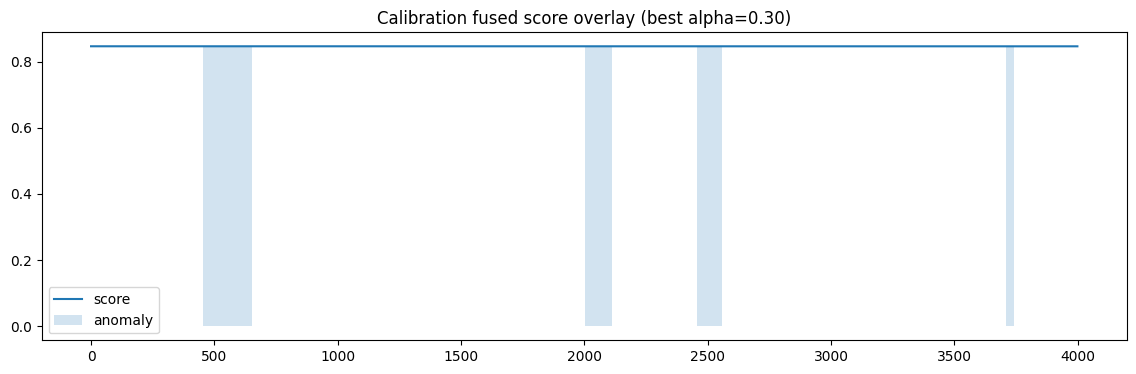

Collect qualitative test outputs: 100%|██████████| 403/403 [00:10<00:00, 39.44it/s]
(2026-06-09 19:41:44,994) [INFO]: Register evaluations
INFO:logger:Register evaluations
(2026-06-09 19:41:44,997) [INFO]: Perform evaluations. Method[Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout], Schema[naive].
INFO:logger:Perform evaluations. Method[Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout], Schema[naive].
(2026-06-09 19:41:44,999) [INFO]:     [Load Data (All)] DataSets: MSL_HybridHoldout 
INFO:logger:    [Load Data (All)] DataSets: MSL_HybridHoldout 
(2026-06-09 19:41:45,023) [INFO]:     [Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout] Eval dataset MSL_HybridHoldout <<<
INFO:logger:    [Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout] Eval dataset MSL_HybridHoldout <<<
(2026-06-09 19:41:45,025) [INFO]:         [MSL_HybridHoldout] Using default margins (0, 5)
INFO:logger:        [MSL_HybridHoldout] Using default margins (0, 5)



Saved qualitative outputs to:
/content/KAN-AD/qualitative_outputs/DeepSKAN_MSL_HybridHoldout_qualitative.npz


In [ ]:
# Cell 10 — Run the EasyTSAD experiment on the holdout dataset

gctrl = TSADController()

gctrl.set_dataset(
    dataset_type="MTS",
    dirname="/content/KAN-AD/datasets",
    datasets=[CUSTOM_DATASET],
)

# ✅ FIXED: must match class name in Cell 8
METHOD_NAME = "Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout"

TRAINING_SCHEMA = "naive"

gctrl.run_exps(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
    cfg_path=CFG_PATH,
)

gctrl.set_evals([
    PointF1PA(),
    EventF1PA(mode="squeeze"),
    PointKthF1PA(k=5),
    PointAuprcPA(),
])

gctrl.do_evals(
    method=METHOD_NAME,
    training_schema=TRAINING_SCHEMA,
)

In [ ]:

# Cell 11 — Load and display EasyTSAD evaluation results

BASE_EVAL = "/content/KAN-AD/Results/Evals"
if not os.path.exists(BASE_EVAL):
    BASE_EVAL = "/content/KAN-AD/KAN-AD/Results/Evals"

avg_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "avg.json"), recursive=True)
all_files = glob.glob(os.path.join(BASE_EVAL, "**", CUSTOM_DATASET, "all.json"), recursive=True)

print("Found avg.json:", avg_files)
print("Found all.json:", all_files)

assert avg_files, "avg.json not found"
assert all_files, "all.json not found"

avg_path = avg_files[0]
all_path = all_files[0]

with open(avg_path, "r") as f:
    avg = json.load(f)

with open(all_path, "r") as f:
    all_scores = json.load(f)

print("\n=== AVERAGE RESULTS (holdout final test) ===")
for k, v in avg.items():
    print(f"{k}: {v}")

print("\n=== PER-SERIES RESULTS ===")
print("Number of series:", len(all_scores))
if len(all_scores) > 0:
    print("Example entry:", list(all_scores.items())[0])

Found avg.json: ['/content/KAN-AD/Results/Evals/Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/avg.json']
Found all.json: ['/content/KAN-AD/Results/Evals/Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/all.json']

=== AVERAGE RESULTS (holdout final test) ===
best f1 under pa: {'f1': 0.9237415477084893, 'precision': 0.9149767441860465, 'recall': 0.932675896074341, 'threshold': 0.0018585920333862305}
event-based f1 under pa with mode squeeze: {'f1': 0.2777777777777773, 'precision': 0.3846153846153846, 'recall': 0.21739130434782608, 'threshold': 0.019651591777801514}
best f1 under 5-delay pa: {'f1': 0.3485730119146574, 'precision': 0.6467866323907455, 'recall': 0.23857386686895504, 'threshold': 0.0018055438995361328}
point-based auprc pa: 0.9340203051728568

=== PER-SERIES RESULTS ===
Number of series: 1
Example entry: ('AllInOne', {'best f1 under pa': {'f1': 0.9237415477084893, 'precision': 0.9149767441860465, 'recall': 0.932675896074341, 'threshold':

In [ ]:

# Cell 12 — Optional: inspect runtime stats and selected alpha

BASE_RUNTIME = "/content/KAN-AD/Results/RunTime"
if not os.path.exists(BASE_RUNTIME):
    BASE_RUNTIME = "/content/KAN-AD/KAN-AD/Results/RunTime"

runtime_files = glob.glob(
    os.path.join(BASE_RUNTIME, "**", METHOD_NAME, TRAINING_SCHEMA, CUSTOM_DATASET, "*.json"),
    recursive=True
)
print("Runtime files:", runtime_files[:5])

for fp in runtime_files[:5]:
    print("\n---", fp, "---")
    try:
        print(json.dumps(json.load(open(fp, "r")), indent=2)[:3000])
    except Exception as e:
        print("Could not read:", e)

Runtime files: ['/content/KAN-AD/Results/RunTime/Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/time.json']

--- /content/KAN-AD/Results/RunTime/Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout/naive/MSL_HybridHoldout/time.json ---
{
  "train_and_valid": 324.540918918,
  "test": 11.279852456999834
}


In [ ]:
# Cell 13 — Save a compact summary for thesis/report comparison

summary_row = {
    "model": METHOD_NAME,
    "dataset": CUSTOM_DATASET,
    "original_dataset": "MSL",   # ✅ FIXED
    "training_schema": TRAINING_SCHEMA,
    "config_path": CFG_PATH,
    "window": 96,
    "order": 2,
    "lambda_svdd": 0.1,
    "emb_dim": 64,
    "calibration_dir": CALIB_DIR,
    "final_test_dir": custom_curve_dir,
}

# Add evaluation metrics
for k, v in avg.items():
    summary_row[k] = v

# Save summary
summary_path = f"/content/{METHOD_NAME}_{CUSTOM_DATASET}_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary_row, f, indent=2)

print("Saved summary to:", summary_path)

print("\nSummary row:")
for k, v in summary_row.items():
    print(f"{k}: {v}")

Saved summary to: /content/Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout_MSL_HybridHoldout_summary.json

Summary row:
model: Attn_WaveletKANAD_SVDD_AlphaTuned_Holdout
dataset: MSL_HybridHoldout
original_dataset: MSL
training_schema: naive
config_path: /content/KAN-AD/kanad/config_attn_waveletkanad_svdd_alpha_holdout.toml
window: 96
order: 2
lambda_svdd: 0.1
emb_dim: 64
calibration_dir: /content/KAN-AD/kanad_runtime/MSL_HybridHoldout_calibration
final_test_dir: /content/KAN-AD/datasets/MTS/MSL_HybridHoldout/AllInOne
best f1 under pa: {'f1': 0.9237415477084893, 'precision': 0.9149767441860465, 'recall': 0.932675896074341, 'threshold': 0.0018585920333862305}
event-based f1 under pa with mode squeeze: {'f1': 0.2777777777777773, 'precision': 0.3846153846153846, 'recall': 0.21739130434782608, 'threshold': 0.019651591777801514}
best f1 under 5-delay pa: {'f1': 0.3485730119146574, 'precision': 0.6467866323907455, 'recall': 0.23857386686895504, 'threshold': 0.0018055438995361328}
point-based auprc 

In [ ]:
# Cell 14 — Load qualitative outputs saved during test_phase

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_NAME = "MSL"
CUSTOM_DATASET = "MSL_HybridHoldout"
FIG_DIR = f"/content/KAN-AD/qualitative_figures/{DATASET_NAME}"
os.makedirs(FIG_DIR, exist_ok=True)

QUAL_PATH = f"/content/KAN-AD/qualitative_outputs/DeepSKAN_{CUSTOM_DATASET}_qualitative.npz"
assert os.path.exists(QUAL_PATH), f"Qualitative file not found: {QUAL_PATH}"

qual = np.load(QUAL_PATH, allow_pickle=True)

print("Loaded:", QUAL_PATH)
print("Available arrays:")
for k in qual.files:
    arr = qual[k]
    print(f"{k:25s}", arr.shape, arr.dtype)

X = qual["test_data"]
y = qual["test_label"].astype(int)
pred_error = qual["pred_error"]
svdd_distance = qual["svdd_distance"]
final_score = qual["final_score"]
Z = qual["embeddings"]
window_labels = qual["window_labels"].astype(int)

best_threshold = float(qual["best_calib_threshold"][0]) if "best_calib_threshold" in qual.files else None
selected_alpha = float(qual["alpha"][0]) if "alpha" in qual.files else None

print("Test data shape:", X.shape)
print("Labels shape:", y.shape, "positive points:", int(y.sum()))
print("Embeddings shape:", Z.shape)
print("Selected alpha:", selected_alpha)
print("Calibration threshold:", best_threshold)


Loaded: /content/KAN-AD/qualitative_outputs/DeepSKAN_MSL_HybridHoldout_qualitative.npz
Available arrays:
test_data                 (51611, 55) float64
test_label                (51611,) bool
pred_error                (51611,) float64
svdd_distance             (51611,) float64
final_score               (51611,) float64
pred_error_windowed       (51515,) float64
svdd_distance_windowed    (51515,) float64
final_score_windowed      (51515,) float64
window_labels             (51515,) int64
embeddings                (51515, 64) float32
normal_attn               (55, 55) float32
anomaly_attn              (55, 55) float32
alpha                     (1,) float32
best_calib_event_f1       (1,) float32
best_calib_threshold      (1,) float32
alpha_tuning_table        (11, 5) float64
alpha_tuning_columns      (5,) object
history                   (7, 5) float64
history_columns           (5,) object
pred_mu                   (1,) float64
pred_std                  (1,) float64
svdd_mu                 

Selected anomaly segment: (16928, 17108)
Plot range: (16141, 17741)
Selected sensor indices: [ 0 31 53]
Saved figure to: /content/KAN-AD/qualitative_figures/MSL/fig1_multichannel_tracking_msl.png


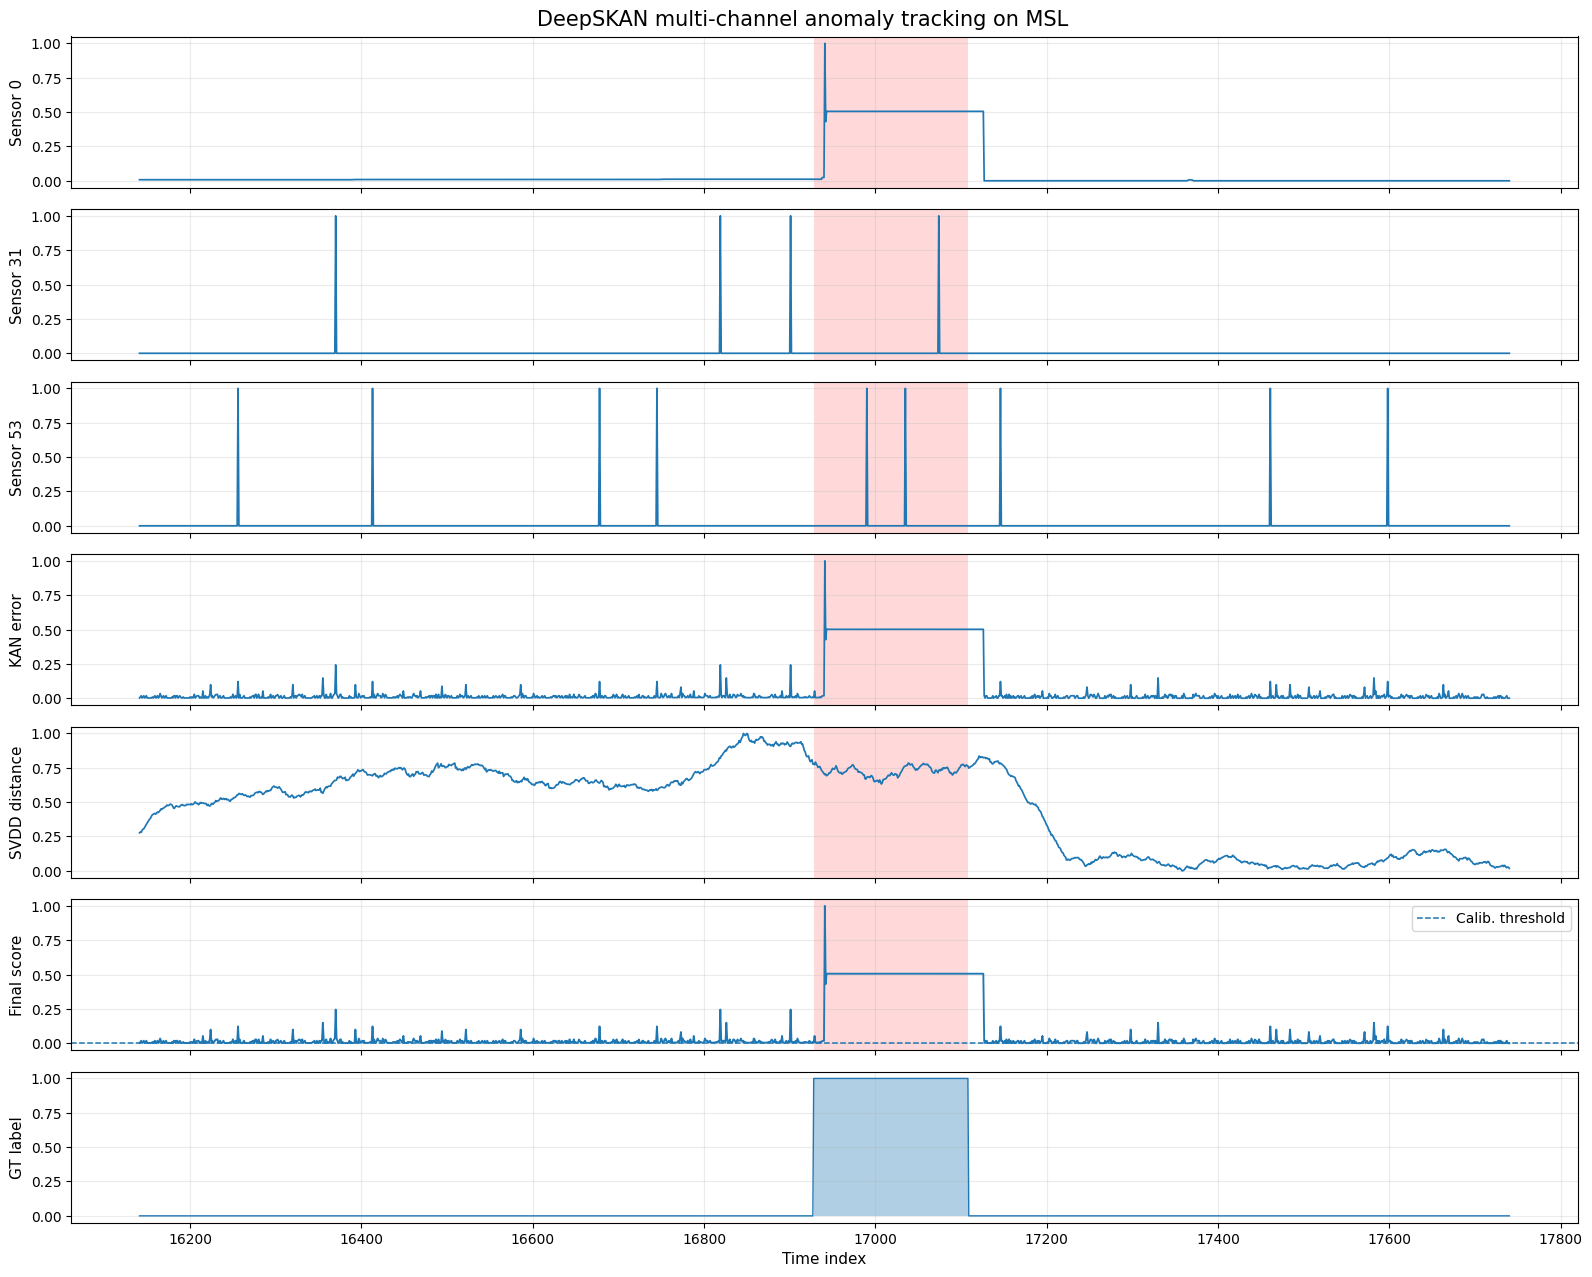

In [ ]:
# Cell 15 — Figure 1: Improved multi-channel anomaly tracking plot


# Helper functions for report-quality plots

import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

def normalize_plot(a):
    a = np.asarray(a, dtype=float)
    amin, amax = np.nanmin(a), np.nanmax(a)
    return (a - amin) / (amax - amin + 1e-8)

def contiguous_segments(labels):
    labels = np.asarray(labels).astype(int)
    idx = np.where(labels > 0)[0]
    if len(idx) == 0:
        return []
    segs = []
    start = idx[0]
    prev = idx[0]
    for i in idx[1:]:
        if i == prev + 1:
            prev = i
        else:
            segs.append((start, prev))
            start = prev = i
    segs.append((start, prev))
    return segs

def choose_best_visible_anomaly_segment(labels, score, min_len=10):
    """Choose anomaly segment where the final score has a strong response."""
    segs = contiguous_segments(labels)
    assert len(segs) > 0, "No anomaly segments found."
    candidates = []
    for s, e in segs:
        length = e - s + 1
        if length < min_len:
            continue
        local_score = np.nanmax(score[s:e+1])
        local_mean = np.nanmean(score[s:e+1])
        candidates.append((local_score, local_mean, length, s, e))
    if len(candidates) == 0:
        # fallback to longest segment
        s, e = max(segs, key=lambda x: x[1] - x[0])
        return s, e
    candidates.sort(reverse=True)
    _, _, _, s, e = candidates[0]
    return s, e

def shade_anomalies(ax, t, labels, color="red", alpha=0.16):
    local = np.asarray(labels).astype(int)
    segs = contiguous_segments(local)
    for s, e in segs:
        ax.axvspan(t[s], t[e], color=color, alpha=alpha, linewidth=0)

def savefig_report(path):
    plt.savefig(path, dpi=350, bbox_inches="tight")
    print("Saved figure to:", path)


# Pick anomaly segment with strongest final-score response
seg_start, seg_end = choose_best_visible_anomaly_segment(y, final_score, min_len=10)
center = int(np.nanargmax(final_score[seg_start:seg_end+1]) + seg_start)

# Wider context around anomaly
context = 800
left = max(0, center - context)
right = min(len(y), center + context)
t = np.arange(left, right)
local_labels = y[left:right]

# Choose top sensors by absolute change/variation in the displayed interval
segment = X[left:right]
feature_variation = np.nanstd(segment, axis=0)
top_features = np.argsort(feature_variation)[-3:][::-1]

print("Selected anomaly segment:", (seg_start, seg_end))
print("Plot range:", (left, right))
print("Selected sensor indices:", top_features)

fig, axes = plt.subplots(7, 1, figsize=(16, 13), sharex=True)

for i, f in enumerate(top_features):
    axes[i].plot(t, normalize_plot(X[left:right, f]), linewidth=1.25)
    axes[i].set_ylabel(f"Sensor {f}")
    axes[i].grid(alpha=0.25)

axes[3].plot(t, normalize_plot(pred_error[left:right]), linewidth=1.25)
axes[3].set_ylabel("KAN error")
axes[3].grid(alpha=0.25)

axes[4].plot(t, normalize_plot(svdd_distance[left:right]), linewidth=1.25)
axes[4].set_ylabel("SVDD distance")
axes[4].grid(alpha=0.25)

axes[5].plot(t, normalize_plot(final_score[left:right]), linewidth=1.35)
axes[5].set_ylabel("Final score")
axes[5].grid(alpha=0.25)

# Optional calibration threshold for final score
if best_threshold is not None:
    thr_norm = normalize_plot(np.array([np.nanmin(final_score[left:right]), best_threshold, np.nanmax(final_score[left:right])]))[1]
    axes[5].axhline(thr_norm, linestyle="--", linewidth=1.1, label="Calib. threshold")
    axes[5].legend(loc="upper right")

# Label track at the bottom for clarity
axes[6].plot(t, local_labels, linewidth=1.0)
axes[6].fill_between(t, 0, local_labels, where=local_labels > 0, alpha=0.35)
axes[6].set_ylabel("GT label")
axes[6].set_xlabel("Time index")
axes[6].set_ylim(-0.05, 1.05)
axes[6].grid(alpha=0.25)

# Red shaded anomaly regions in all panels
for ax in axes[:-1]:
    shade_anomalies(ax, t, local_labels, color="red", alpha=0.15)

plt.suptitle(f"DeepSKAN multi-channel anomaly tracking on {DATASET_NAME}", fontsize=15)
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, f"fig1_multichannel_tracking_{DATASET_NAME.lower()}.png")
savefig_report(fig_path)
plt.show()


In [ ]:
# Cell 16 — Interactive 3D PCA latent-space visualization for MSL

!pip install -q plotly

import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.decomposition import PCA
import os

assert len(Z) == len(window_labels), "Embeddings and window labels are not aligned."

normal_idx = np.where(window_labels == 0)[0]
anom_idx = np.where(window_labels > 0)[0]

print("Windowed normal samples:", len(normal_idx))
print("Windowed anomaly samples:", len(anom_idx))

# -----------------------------
# Balanced sampling for clarity
# -----------------------------
np.random.seed(42)

n_normal = min(5000, len(normal_idx))
n_anom = min(5000, len(anom_idx))

sample_parts = []

if n_normal > 0:
    sample_parts.append(np.random.choice(normal_idx, n_normal, replace=False))

if n_anom > 0:
    sample_parts.append(np.random.choice(anom_idx, n_anom, replace=False))

assert len(sample_parts) > 0, "No samples available for PCA plot."

sample_idx = np.concatenate(sample_parts)

Z_sample = Z[sample_idx]
y_sample = window_labels[sample_idx]

label_text = np.where(y_sample > 0, "Anomalous windows", "Normal windows")

# -----------------------------
# PCA to 3D
# -----------------------------
pca = PCA(n_components=3)
Z_3d = pca.fit_transform(Z_sample)
explained = pca.explained_variance_ratio_ * 100

print("Explained variance ratio:", pca.explained_variance_ratio_)
print(f"Total explained variance: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

# -----------------------------
# Build dataframe for Plotly
# -----------------------------
plot_df = pd.DataFrame({
    "PC1": Z_3d[:, 0],
    "PC2": Z_3d[:, 1],
    "PC3": Z_3d[:, 2],
    "Class": label_text,
})

# -----------------------------
# Interactive 3D plot
# -----------------------------
fig = px.scatter_3d(
    plot_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Class",
    opacity=0.65,
    title=(
        f"DeepSKAN latent-space projection on {DATASET_NAME} (Interactive 3D PCA)<br>"
        f"PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%, PC3={explained[2]:.1f}%"
    )
)

fig.update_traces(marker=dict(size=3))

fig.update_layout(
    width=950,
    height=700,
    legend_title_text="Window type",
    scene=dict(
        xaxis_title=f"PC1 ({explained[0]:.1f}%)",
        yaxis_title=f"PC2 ({explained[1]:.1f}%)",
        zaxis_title=f"PC3 ({explained[2]:.1f}%)",
    )
)

fig.show()

# -----------------------------
# Save interactive HTML
# -----------------------------
html_path = os.path.join(
    FIG_DIR,
    f"fig2_interactive_pca3d_{DATASET_NAME.lower()}.html"
)

fig.write_html(html_path)

print("Saved interactive 3D PCA plot to:", html_path)

Windowed normal samples: 46357
Windowed anomaly samples: 5158
Explained variance ratio: [9.9905944e-01 2.1341861e-04 7.8975856e-05]
Total explained variance: 99.94%


Saved interactive 3D PCA plot to: /content/KAN-AD/qualitative_figures/MSL/fig2_interactive_pca3d_msl.html


In [ ]:
# Cell 17 — Optional Figure 2b: t-SNE latent-space separation
# Run this only if you want a more visually separated nonlinear projection.
# PCA is more stable and should be preferred for the main report unless t-SNE is clearly more readable.

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

RUN_TSNE = False

if RUN_TSNE:
    max_points = 5000
    if len(sample_idx) > max_points:
        rng = np.random.default_rng(42)
        sub = rng.choice(np.arange(len(sample_idx)), max_points, replace=False)
        Z_tsne_input = Z_sample[sub]
        y_tsne = y_sample[sub]
    else:
        Z_tsne_input = Z_sample
        y_tsne = y_sample

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=42
    )
    Z_tsne = tsne.fit_transform(Z_tsne_input)

    plt.figure(figsize=(8.5, 6.4))
    plt.scatter(Z_tsne[y_tsne == 0, 0], Z_tsne[y_tsne == 0, 1], s=9, alpha=0.38, label="Normal windows")
    plt.scatter(Z_tsne[y_tsne > 0, 0], Z_tsne[y_tsne > 0, 1], s=10, alpha=0.70, label="Anomalous windows")
    plt.title(f"DeepSKAN latent-space projection on {DATASET_NAME} (t-SNE)")
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.legend(frameon=True)
    plt.grid(alpha=0.25)

    fig_path = os.path.join(FIG_DIR, f"fig2b_latent_space_tsne_{DATASET_NAME.lower()}.png")
    savefig_report(fig_path)
    plt.show()
else:
    print("t-SNE skipped. Set RUN_TSNE=True to generate it.")


t-SNE skipped. Set RUN_TSNE=True to generate it.


normal_attn shape: (55, 55)
anomaly_attn shape: (55, 55)
Saved figure to: /content/KAN-AD/qualitative_figures/MSL/fig3_attention_heatmaps_difference_msl.png


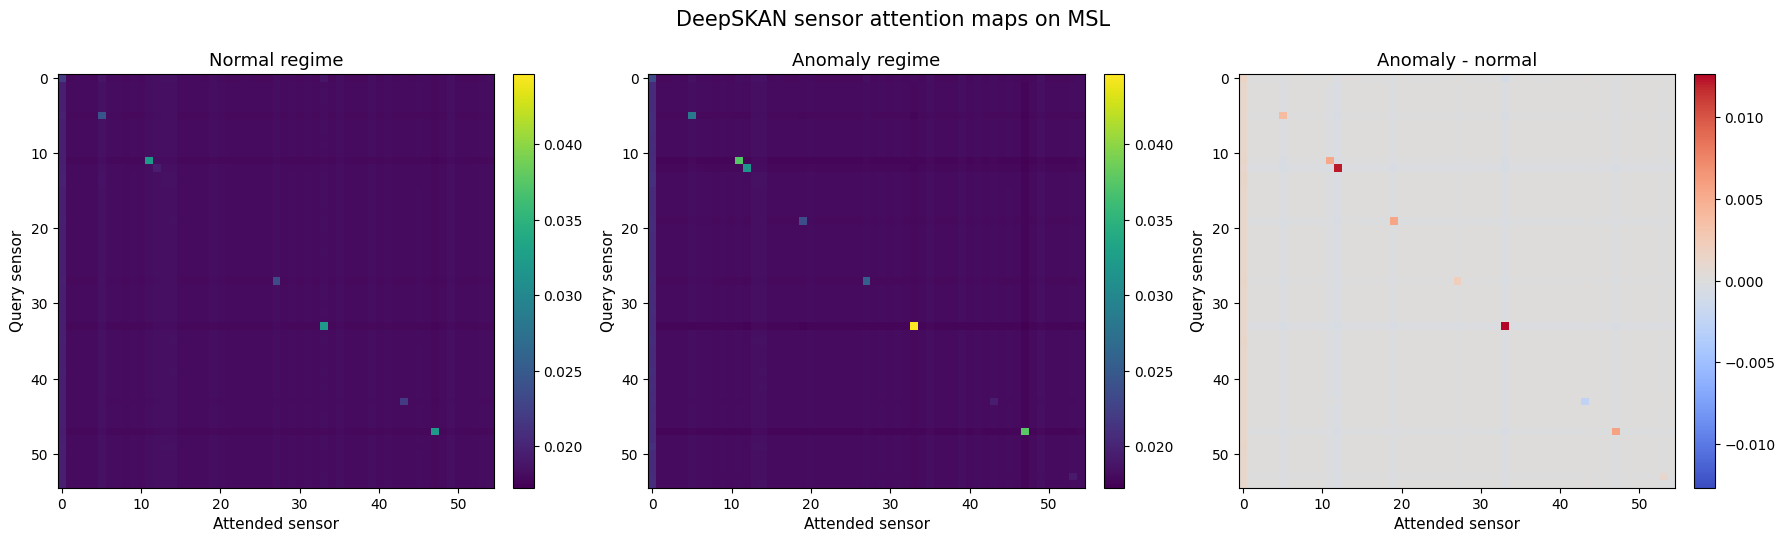

Saved figure to: /content/KAN-AD/qualitative_figures/MSL/fig3b_top_attention_shift_sensors_msl.png


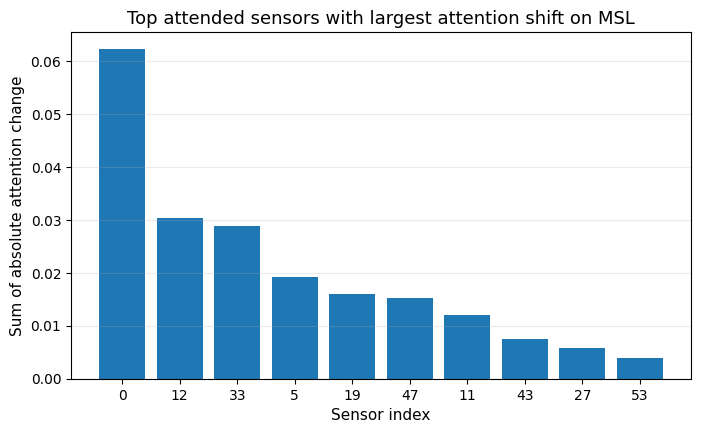

In [ ]:
# Cell 18 — Figure 3: Improved sensor attention heatmaps with difference map

import numpy as np
import matplotlib.pyplot as plt
import os

normal_attn = qual["normal_attn"]
anomaly_attn = qual["anomaly_attn"]

print("normal_attn shape:", normal_attn.shape)
print("anomaly_attn shape:", anomaly_attn.shape)

assert normal_attn.size > 0, "No normal attention matrix saved. Re-run test_phase or reduce batch size."
assert anomaly_attn.size > 0, "No anomaly attention matrix saved. Re-run test_phase or choose a test split containing anomaly batches."

# Difference map makes attention changes easier to interpret
diff_attn = anomaly_attn - normal_attn
abs_diff = np.abs(diff_attn)

# Same color scale for fair comparison of normal and anomaly attention
vmin = min(float(np.nanmin(normal_attn)), float(np.nanmin(anomaly_attn)))
vmax = max(float(np.nanmax(normal_attn)), float(np.nanmax(anomaly_attn)))

diff_vmax = float(np.nanmax(np.abs(diff_attn)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

im0 = axes[0].imshow(normal_attn, aspect="auto", vmin=vmin, vmax=vmax)
axes[0].set_title("Normal regime")
axes[0].set_xlabel("Attended sensor")
axes[0].set_ylabel("Query sensor")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(anomaly_attn, aspect="auto", vmin=vmin, vmax=vmax)
axes[1].set_title("Anomaly regime")
axes[1].set_xlabel("Attended sensor")
axes[1].set_ylabel("Query sensor")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(diff_attn, aspect="auto", vmin=-diff_vmax, vmax=diff_vmax, cmap="coolwarm")
axes[2].set_title("Anomaly - normal")
axes[2].set_xlabel("Attended sensor")
axes[2].set_ylabel("Query sensor")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f"DeepSKAN sensor attention maps on {DATASET_NAME}", fontsize=15)
plt.tight_layout()

fig_path = os.path.join(FIG_DIR, f"fig3_attention_heatmaps_difference_{DATASET_NAME.lower()}.png")
savefig_report(fig_path)
plt.show()

# Additional top-k plot: which attended sensors changed the most?
# Sum absolute changes over query sensors.
sensor_change = abs_diff.sum(axis=0)
top_k = min(10, len(sensor_change))
top_idx = np.argsort(sensor_change)[-top_k:][::-1]

plt.figure(figsize=(8, 4.5))
plt.bar([str(i) for i in top_idx], sensor_change[top_idx])
plt.title(f"Top attended sensors with largest attention shift on {DATASET_NAME}")
plt.xlabel("Sensor index")
plt.ylabel("Sum of absolute attention change")
plt.grid(axis="y", alpha=0.25)

fig_path = os.path.join(FIG_DIR, f"fig3b_top_attention_shift_sensors_{DATASET_NAME.lower()}.png")
savefig_report(fig_path)
plt.show()


,epoch,train_total_loss,valid_total_loss,train_pred_loss,train_svdd_loss
0,1.0,7693.6486,7693.07936,7693.000169,6.484354
1,2.0,NaN,NaN,NaN,NaN
2,3.0,NaN,NaN,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN
4,5.0,NaN,NaN,NaN,NaN
5,6.0,NaN,NaN,NaN,NaN
6,7.0,NaN,NaN,NaN,NaN


Saved figure to: /content/KAN-AD/qualitative_figures/MSL/fig4_loss_convergence_msl.png


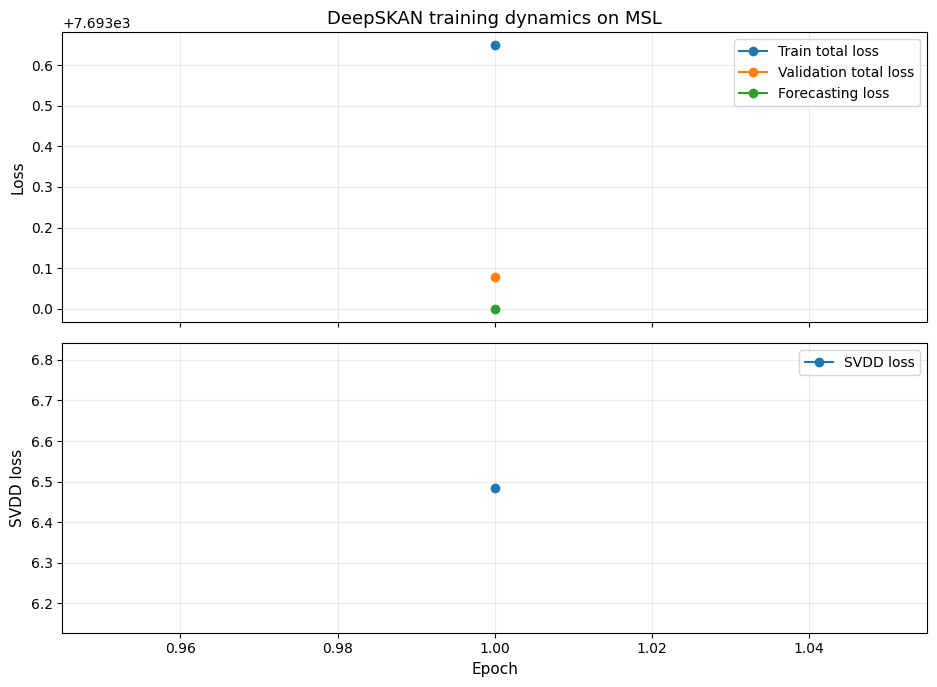

,alpha,event_f1,precision,recall,threshold
0,0.0,0.000000,0.000000,0.000000,0.999665
1,0.1,0.250000,0.666667,0.153846,0.948438
2,0.2,0.250000,0.666667,0.153846,0.897212
3,0.3,0.266667,1.000000,0.153846,0.845985
4,0.4,0.266667,1.000000,0.153846,0.794758
5,0.5,0.266667,1.000000,0.153846,0.743532
6,0.6,0.266667,1.000000,0.153846,0.692305
7,0.7,0.266667,1.000000,0.153846,0.641079
8,0.8,0.266667,1.000000,0.153846,0.589852
9,0.9,0.266667,1.000000,0.153846,0.538625


Saved figure to: /content/KAN-AD/qualitative_figures/MSL/fig5_alpha_sweep_msl.png


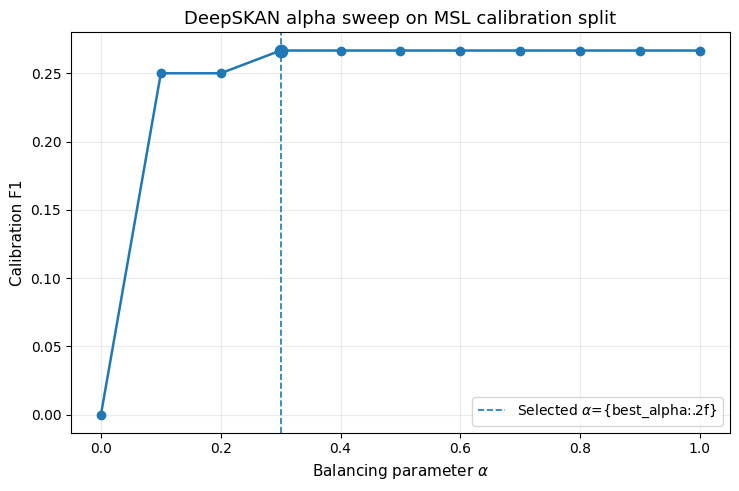

In [ ]:
# Cell 19 — Improved loss convergence and alpha-sweep plots

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------
# Loss convergence with separate axis for SVDD loss
# -----------------------------
history = qual["history"]
history_columns = [str(c) for c in qual["history_columns"]]

if history.size > 0:
    hist_df = pd.DataFrame(history, columns=history_columns)
    display(hist_df)

    fig, axes = plt.subplots(2, 1, figsize=(9.5, 7), sharex=True)

    axes[0].plot(hist_df["epoch"], hist_df["train_total_loss"], marker="o", label="Train total loss")
    axes[0].plot(hist_df["epoch"], hist_df["valid_total_loss"], marker="o", label="Validation total loss")
    axes[0].plot(hist_df["epoch"], hist_df["train_pred_loss"], marker="o", label="Forecasting loss")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"DeepSKAN training dynamics on {DATASET_NAME}")
    axes[0].grid(alpha=0.25)
    axes[0].legend(frameon=True)

    axes[1].plot(hist_df["epoch"], hist_df["train_svdd_loss"], marker="o", label="SVDD loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("SVDD loss")
    axes[1].grid(alpha=0.25)
    axes[1].legend(frameon=True)

    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, f"fig4_loss_convergence_{DATASET_NAME.lower()}.png")
    savefig_report(fig_path)
    plt.show()
else:
    print("No history saved.")

# -----------------------------
# Alpha sweep
# -----------------------------
alpha_table = qual["alpha_tuning_table"]
alpha_columns = [str(c) for c in qual["alpha_tuning_columns"]]

if alpha_table.size > 0:
    alpha_df = pd.DataFrame(alpha_table, columns=alpha_columns)
    display(alpha_df)

    metric_col = "event_f1" if "event_f1" in alpha_df.columns else alpha_df.columns[1]
    plt.figure(figsize=(8.5, 5.2))
    plt.plot(alpha_df["alpha"], alpha_df[metric_col], marker="o", linewidth=1.8)

    best_alpha = float(qual["alpha"][0])
    best_idx = int(np.nanargmax(alpha_df[metric_col].values))
    best_metric = float(alpha_df.iloc[best_idx][metric_col])

    plt.axvline(best_alpha, linestyle="--", linewidth=1.2, label=fr"Selected $\alpha$={{best_alpha:.2f}}")
    plt.scatter([best_alpha], [best_metric], s=80, zorder=5)
    plt.xlabel(r"Balancing parameter $\alpha$")
    plt.ylabel("Calibration F1")
    plt.title(f"DeepSKAN alpha sweep on {DATASET_NAME} calibration split")
    plt.grid(alpha=0.25)
    plt.legend(frameon=True)

    fig_path = os.path.join(FIG_DIR, f"fig5_alpha_sweep_{DATASET_NAME.lower()}.png")
    savefig_report(fig_path)
    plt.show()
else:
    print("No alpha tuning table saved.")


In [ ]:
# Cell 20 — Ready-to-use qualitative-analysis paragraph for the report

paragraph = rf"""
For qualitative analysis, we visualize the internal behavior of DeepSKAN on representative {DATASET_NAME} anomaly intervals.
The multi-channel anomaly tracking plot compares selected raw sensor streams with the WaveletKAN forecasting error,
the DeepSVDD latent distance, and the final combined anomaly score. Red-shaded regions correspond to the ground-truth
anomalous timestamps. This figure illustrates how the forecasting and boundary-learning components respond to abnormal
behavior and how their calibrated fusion produces the final anomaly score.

The latent-space projection uses PCA to visualize DeepSKAN embeddings. Normal windows form a denser central region,
while anomalous windows tend to spread toward the margins or form outlying clusters. This supports the role of the
DeepSVDD branch in learning a compact representation of normal operating states.

The attention heatmaps compare sensor-level attention during normal and anomalous regimes. The additional difference map
highlights which sensor interactions receive altered importance during anomalies, providing an interpretable view of how
the attention module contributes to multivariate dependency modeling.
"""

print(paragraph)



For qualitative analysis, we visualize the internal behavior of DeepSKAN on representative MSL anomaly intervals.
The multi-channel anomaly tracking plot compares selected raw sensor streams with the WaveletKAN forecasting error,
the DeepSVDD latent distance, and the final combined anomaly score. Red-shaded regions correspond to the ground-truth
anomalous timestamps. This figure illustrates how the forecasting and boundary-learning components respond to abnormal
behavior and how their calibrated fusion produces the final anomaly score.

The latent-space projection uses PCA to visualize DeepSKAN embeddings. Normal windows form a denser central region,
while anomalous windows tend to spread toward the margins or form outlying clusters. This supports the role of the
DeepSVDD branch in learning a compact representation of normal operating states.

The attention heatmaps compare sensor-level attention during normal and anomalous regimes. The additional difference map
highlights which senso